Minggu 1 : Gathering & Assesing

W1: CRAWLING DATA NASA POWER DAV

Periode: 2020–2025 | 3 lokasi | Resolusi: Hourly

Output: sanur_bali.csv, senggigi_lombok.csv, waisai_raja_ampat.csv


In [1]:
import pandas as pd

# Jika sudah download manual dari NASA DAV, langsung load saja
def load_nasa_csv(filepath, lokasi):
    """
    Load CSV hasil download NASA POWER DAV.
    Skip 14 baris header NASA, tambah kolom LOKASI.
    """
    df = pd.read_csv(filepath, skiprows=14)
    df.columns = df.columns.str.strip()
    df['LOKASI'] = lokasi
    print(f"✅ {lokasi} loaded: {df.shape[0]:,} baris, {df.shape[1]} kolom")
    return df

df_bali   = load_nasa_csv('Pantai Sanur - Bali.csv',      'Bali')
df_lombok = load_nasa_csv('Pantai Senggigi - Lombok.csv', 'Lombok')
df_raja   = load_nasa_csv('Waisai - Raja Ampat.csv',      'Raja Ampat')

# Gabungkan semua lokasi
df_raw = pd.concat([df_bali, df_lombok, df_raja], ignore_index=True)

print(f"\nTotal data gabungan: {len(df_raw):,} baris")
print(f"Kolom: {list(df_raw.columns)}")
print(f"Periode: {df_raw['YEAR'].min()}–{df_raw['YEAR'].max()}")
print(f"Lokasi: {df_raw['LOKASI'].unique()}")

df_raw.to_csv('raw_data_gabungan.csv', index=False)
print("\nRaw data disimpan → raw_data_gabungan.csv ✅")

✅ Bali loaded: 52,608 baris, 11 kolom
✅ Lombok loaded: 52,608 baris, 11 kolom
✅ Raja Ampat loaded: 52,608 baris, 11 kolom

Total data gabungan: 157,824 baris
Kolom: ['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SFC_UV_INDEX', 'T2M', 'WS2M', 'RH2M', 'LOKASI']
Periode: 2020–2025
Lokasi: ['Bali' 'Lombok' 'Raja Ampat']

Raw data disimpan → raw_data_gabungan.csv ✅


W1-W2: GATHERING & ASSESSING
Dataset diperoleh dari NASA POWER Data Access Viewer (DAV)
dengan resolusi temporal per jam (hourly) dari 3 lokasi:
Pantai Sanur (Bali), Pantai Senggigi (Lombok), dan Waisai (Raja Ampat).
Periode data: Januari 2020 – Desember 2025.

In [2]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('raw_data_gabungan.csv')

cols_numerik = [
    'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SFC_UV_INDEX',
    'T2M', 'WS2M', 'RH2M'
]


print("=" * 60)
print("ASSESSING - STRUKTUR DATA")
print("=" * 60)

# 1. Info umum
print("\n[1] Shape dataset:")
print(f"    Baris: {df_raw.shape[0]:,} | Kolom: {df_raw.shape[1]}")

# 2. Tipe data
print("\n[2] Tipe data tiap kolom:")
print(df_raw.dtypes)

# 3. Missing values
print("\n[3] Missing values:")
mv = df_raw.isnull().sum()
mv_pct = (mv / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Jumlah': mv, 'Persen (%)': mv_pct}))

# 4. Duplikat
print(f"\n[4] Duplikat: {df_raw.duplicated().sum()} baris")

# 5. Nilai -999 (kode NASA untuk data tidak tersedia)
print("\n[5] Nilai -999 (missing NASA):")
for col in cols_numerik:
    jml = (df_raw[col] == -999).sum()
    print(f"    {col}: {jml:,} nilai")

# 6. Statistik deskriptif
print("\n[6] Statistik Deskriptif:")
print(df_raw[cols_numerik].describe().round(3))

# 7. Jumlah data per lokasi
print("\n[7] Jumlah baris per lokasi:")
print(df_raw['LOKASI'].value_counts())

# 8. Rentang tahun per lokasi
print("\n[8] Rentang tahun per lokasi:")
print(df_raw.groupby('LOKASI')['YEAR'].agg(['min','max']))


ASSESSING - STRUKTUR DATA

[1] Shape dataset:
    Baris: 157,824 | Kolom: 11

[2] Tipe data tiap kolom:
YEAR                     int64
MO                       int64
DY                       int64
HR                       int64
ALLSKY_SFC_UVA         float64
ALLSKY_SFC_UVB         float64
ALLSKY_SFC_UV_INDEX    float64
T2M                    float64
WS2M                   float64
RH2M                   float64
LOKASI                  object
dtype: object

[3] Missing values:
                     Jumlah  Persen (%)
YEAR                      0         0.0
MO                        0         0.0
DY                        0         0.0
HR                        0         0.0
ALLSKY_SFC_UVA            0         0.0
ALLSKY_SFC_UVB            0         0.0
ALLSKY_SFC_UV_INDEX       0         0.0
T2M                       0         0.0
WS2M                      0         0.0
RH2M                      0         0.0
LOKASI                    0         0.0

[4] Duplikat: 0 baris

[5] Nilai -999 (

Temuan Assessing
- Tidak ada missing value (NaN) langsung dari NASA
- Nilai -999 merupakan kode NASA untuk data tidak tersedia
- Tidak ada duplikat
- Jumlah data per lokasi seimbang (~52.608 baris/lokasi untuk 6 tahun hourly)

W2: DATA CLEANING

Output: clean_data.csv


In [3]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('raw_data_gabungan.csv')

cols_numerik = [
    'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SFC_UV_INDEX',
    'T2M', 'WS2M', 'RH2M'
]

# -----------------------------------------------------------
# Markdown Cell:
# ## Data Cleaning
# ### Langkah 1: Buat kolom DATETIME
# Menggabungkan kolom YEAR, MO, DY, HR menjadi satu kolom datetime
# untuk memudahkan analisis time series.
# -----------------------------------------------------------

# Step 1: Buat datetime
df['DATETIME'] = pd.to_datetime(
    df[['YEAR','MO','DY','HR']].rename(columns={
        'YEAR':'year','MO':'month','DY':'day','HR':'hour'
    })
)
print("✅ Step 1: Kolom DATETIME dibuat")

# -----------------------------------------------------------
# Markdown Cell:
# ### Langkah 2: Ganti nilai -999 dengan NaN
# Nilai -999 adalah kode NASA untuk data yang tidak tersedia.
# Nilai ini perlu diganti NaN sebelum imputasi agar tidak
# mengganggu perhitungan statistik.
# -----------------------------------------------------------

# Step 2: Ganti -999 → NaN
for col in cols_numerik:
    before = (df[col] == -999).sum()
    df[col] = df[col].replace(-999, np.nan)
    if before > 0:
        print(f"✅ Step 2: {col} — {before:,} nilai -999 diganti NaN")

print(f"\nMissing value setelah replace -999:")
print(df[cols_numerik].isnull().sum())

# -----------------------------------------------------------
# Markdown Cell:
# ### Langkah 3: Imputasi missing value
# Missing value diisi menggunakan **median per lokasi per jam**.
# Alasan: median lebih robust terhadap outlier dibanding mean.
# Imputasi per jam mempertahankan pola sirkadian UV harian.
# -----------------------------------------------------------

# Step 3: Imputasi median per lokasi per jam
for col in cols_numerik:
    sebelum = df[col].isnull().sum()
    df[col] = df.groupby(['LOKASI','HR'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    sesudah = df[col].isnull().sum()
    if sebelum > 0:
        print(f"✅ Step 3: {col} — {sebelum} NaN → {sesudah} NaN (imputasi median)")

# -----------------------------------------------------------
# Markdown Cell:
# ### Langkah 4: Deteksi dan penanganan outlier
# Outlier dideteksi menggunakan Z-score dengan threshold > 4.
# Threshold dipilih lebih longgar (4 bukan 3) karena data cuaca
# tropis memiliki variasi yang lebih ekstrem secara alami.
# Nilai outlier diganti dengan median per lokasi per jam.
# -----------------------------------------------------------

# Step 4: Outlier handling dengan Z-score
for col in cols_numerik:
    before = len(df)
    grp = df.groupby(['LOKASI','HR'])[col]
    z_scores = grp.transform(lambda x: np.abs(stats.zscore(x, nan_policy='omit')))
    outlier_mask = z_scores > 4
    jml_outlier = outlier_mask.sum()
    df.loc[outlier_mask, col] = np.nan
    df[col] = df.groupby(['LOKASI','HR'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    if jml_outlier > 0:
        print(f"✅ Step 4: {col} — {jml_outlier:,} outlier ditangani")

# -----------------------------------------------------------
# Markdown Cell:
# ### Langkah 5: Validasi akhir
# Memastikan tidak ada missing value tersisa dan
# semua nilai berada dalam range yang wajar.
# -----------------------------------------------------------

# Step 5: Validasi akhir
print("\n" + "=" * 50)
print("VALIDASI AKHIR SETELAH CLEANING")
print("=" * 50)
print(f"Missing value tersisa:\n{df[cols_numerik].isnull().sum()}")
print(f"\nDuplikat: {df.duplicated().sum()}")
print(f"\nShape akhir: {df.shape}")
print(f"\nStatistik deskriptif:")
print(df[cols_numerik].describe().round(3))

# Simpan
df.to_csv('clean_data.csv', index=False)
print("\n✅ clean_data.csv disimpan!")

✅ Step 1: Kolom DATETIME dibuat
✅ Step 2: ALLSKY_SFC_UVA — 72 nilai -999 diganti NaN
✅ Step 2: ALLSKY_SFC_UVB — 72 nilai -999 diganti NaN
✅ Step 2: ALLSKY_SFC_UV_INDEX — 72 nilai -999 diganti NaN

Missing value setelah replace -999:
ALLSKY_SFC_UVA         72
ALLSKY_SFC_UVB         72
ALLSKY_SFC_UV_INDEX    72
T2M                     0
WS2M                    0
RH2M                    0
dtype: int64
✅ Step 3: ALLSKY_SFC_UVA — 72 NaN → 0 NaN (imputasi median)
✅ Step 3: ALLSKY_SFC_UVB — 72 NaN → 0 NaN (imputasi median)
✅ Step 3: ALLSKY_SFC_UV_INDEX — 72 NaN → 0 NaN (imputasi median)
✅ Step 4: ALLSKY_SFC_UVA — 115 outlier ditangani
✅ Step 4: ALLSKY_SFC_UVB — 373 outlier ditangani
✅ Step 4: ALLSKY_SFC_UV_INDEX — 129 outlier ditangani
✅ Step 4: WS2M — 50 outlier ditangani
✅ Step 4: RH2M — 158 outlier ditangani

VALIDASI AKHIR SETELAH CLEANING
Missing value tersisa:
ALLSKY_SFC_UVA         0
ALLSKY_SFC_UVB         0
ALLSKY_SFC_UV_INDEX    0
T2M                    0
WS2M                   0
RH2

W2: FEATURE ENGINEERING

Output: dataset_features.csv, feature_spec.md

In [4]:
# ============================================================
# SATRIYO - W2: FEATURE ENGINEERING (UPDATE: Review Aikylla)
# Target: DURASI_AMAN_MENIT (bukan LABEL_AMAN)
# Output: dataset_features.csv, feature_spec.md
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv('clean_data.csv')
df['DATETIME'] = pd.to_datetime(df['DATETIME'])

# --- Fitur 1: Kategori waktu ---
df['JAM_KATEGORI'] = pd.cut(
    df['HR'],
    bins=[-1, 5, 9, 14, 17, 23],
    labels=['Dini Hari', 'Pagi', 'Siang', 'Sore', 'Malam']
)
print("✅ Fitur JAM_KATEGORI dibuat")

# --- Fitur 2: IS_DAYTIME ---
df['IS_DAYTIME'] = df['HR'].between(6, 17).astype(int)
print("✅ Fitur IS_DAYTIME dibuat")

# --- Fitur 3: Bulan & Musim ---
df['BULAN'] = df['MO']
df['MUSIM'] = df['MO'].map({
    12:'Hujan', 1:'Hujan', 2:'Hujan',
    3:'Peralihan', 4:'Peralihan',
    5:'Kemarau', 6:'Kemarau', 7:'Kemarau',
    8:'Kemarau', 9:'Peralihan',
    10:'Peralihan', 11:'Hujan'
})
print("✅ Fitur BULAN & MUSIM dibuat")

# --- [UPDATE] Fitur 4: DURASI_AMAN_MENIT (TARGET BARU) ---
# Formula SED (Standard Erythemal Dose)
# Baseline: Fitzpatrick Type III (MED = 4.5 J/m²)
# Penyesuaian per tipe kulit dilakukan di serving API
MED_BASELINE = 4.5
df['DURASI_AMAN_MENIT'] = df['ALLSKY_SFC_UV_INDEX'].apply(
    lambda uv: round(MED_BASELINE / (uv * 0.0025 * 60), 1) if uv > 0 else 120.0
)
df['DURASI_AMAN_MENIT'] = df['DURASI_AMAN_MENIT'].clip(upper=120.0)
print("✅ DURASI_AMAN_MENIT dibuat (target model)")
print(df['DURASI_AMAN_MENIT'].describe().round(2))

# --- LABEL_AMAN: referensi saja, bukan target model ---
# Threshold konsisten dengan serving API: durasi < 10 menit → Tidak Aman
df['LABEL_AMAN'] = (df['DURASI_AMAN_MENIT'] >= 10).astype(int)
print(f"\n✅ LABEL_AMAN diturunkan dari DURASI_AMAN_MENIT (threshold >= 10 menit)")
print(f"Distribusi LABEL_AMAN:\n{df['LABEL_AMAN'].value_counts()}")
print(f"Proporsi aman: {df['LABEL_AMAN'].mean()*100:.1f}%")

# Filter hanya jam siang (6–17)
df_feat = df[df['HR'].between(6, 17)].copy()
print(f"\nShape setelah filter jam 6–17: {df_feat.shape}")

df_feat.to_csv('dataset_features.csv', index=False)
print("\n✅ dataset_features.csv disimpan!")

# Update feature_spec.md
feature_spec = """# Feature Specification — SYNAR
**Author:** Satriyo | **Diserahkan ke:** Aikylla (Random Forest Regressor)
**Update:** Berdasarkan review Aikylla

## Target Model
| Nama | Tipe | Satuan | Range | Keterangan |
|------|------|--------|-------|------------|
| DURASI_AMAN_MENIT | float | menit | 0–120 | Output Random Forest Regressor |

> Label aman/tidak TIDAK dihasilkan model.
> Diturunkan di serving API: if durasi < 10 → Tidak Aman
> SKIN_TYPE tidak masuk fitur model — penyesuaian di serving API

## Formula DURASI_AMAN_MENIT
MED_BASELINE = 4.5 J/m² (Fitzpatrick Type III)
DURASI = MED_BASELINE / (UV_INDEX × 0.0025 × 60)
Cap maksimal: 120 menit

## Threshold Aman (Konsisten di seluruh pipeline)
DURASI_AMAN_MENIT >= 10 menit → Aman (1)
DURASI_AMAN_MENIT <  10 menit → Tidak Aman (0)

## Fitur Training (X)
| Nama Fitur | Tipe | Satuan | Sumber |
|------------|------|--------|--------|
| ALLSKY_SFC_UV_INDEX | float | W m-2 x 40 | NASA POWER |
| ALLSKY_SFC_UVA | float | MJ/hr | NASA POWER |
| ALLSKY_SFC_UVB | float | MJ/hr | NASA POWER |
| T2M | float | °C | NASA POWER |
| WS2M | float | m/s | NASA POWER |
| RH2M | float | % | NASA POWER |
| HR | int | jam (0–23) | NASA POWER |
| BULAN | int | 1–12 | Feature Engineering |

## Split Dataset — Time-based 80/10/10
| Split | Proporsi | Periode |
|-------|----------|---------|
| Train | 80% | 2020 – mid 2024 |
| Validation | 10% | mid 2024 – late 2024 |
| Test | 10% | late 2024 – 2025 |

Metode: Time-based split (bukan random shuffle)
Alasan: Data time series — random shuffle menyebabkan data leakage
"""

with open('feature_spec.md', 'w') as f:
    f.write(feature_spec)
print("✅ feature_spec.md disimpan!")

✅ Fitur JAM_KATEGORI dibuat
✅ Fitur IS_DAYTIME dibuat
✅ Fitur BULAN & MUSIM dibuat
✅ DURASI_AMAN_MENIT dibuat (target model)
count    157824.00
mean         75.97
std          53.78
min           1.90
25%           7.60
50%         120.00
75%         120.00
max         120.00
Name: DURASI_AMAN_MENIT, dtype: float64

✅ LABEL_AMAN diturunkan dari DURASI_AMAN_MENIT (threshold >= 10 menit)
Distribusi LABEL_AMAN:
LABEL_AMAN
1    113017
0     44807
Name: count, dtype: int64
Proporsi aman: 71.6%

Shape setelah filter jam 6–17: (78912, 18)

✅ dataset_features.csv disimpan!
✅ feature_spec.md disimpan!


In [5]:
# ============================================================
# SPLIT DATASET — TIME-BASED 80/10/10
# Tidak menggunakan random shuffle karena data time series
# ============================================================

import pandas as pd

df = pd.read_csv('dataset_features.csv')
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df = df.sort_values('DATETIME').reset_index(drop=True)

total     = len(df)
train_end = int(total * 0.80)
val_end   = int(total * 0.90)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print("=" * 55)
print("SPLIT DATASET — TIME-BASED 80/10/10")
print("=" * 55)
print(f"Total data  : {total:,} baris")
print(f"Train (80%) : {len(df_train):,} | {df_train['DATETIME'].min().date()} → {df_train['DATETIME'].max().date()}")
print(f"Val   (10%) : {len(df_val):,} | {df_val['DATETIME'].min().date()} → {df_val['DATETIME'].max().date()}")
print(f"Test  (10%) : {len(df_test):,} | {df_test['DATETIME'].min().date()} → {df_test['DATETIME'].max().date()}")

df_train.to_csv('train.csv', index=False)
df_val.to_csv('val.csv',     index=False)
df_test.to_csv('test.csv',   index=False)

print("\n✅ train.csv, val.csv, test.csv disimpan!")
print("\nCatatan: Split berdasarkan urutan waktu (bukan random)")
print("Ini mencegah data leakage pada time series!")

SPLIT DATASET — TIME-BASED 80/10/10
Total data  : 78,912 baris
Train (80%) : 63,129 | 2020-01-01 → 2024-10-19
Val   (10%) : 7,891 | 2024-10-19 → 2025-05-26
Test  (10%) : 7,892 | 2025-05-26 → 2025-12-31

✅ train.csv, val.csv, test.csv disimpan!

Catatan: Split berdasarkan urutan waktu (bukan random)
Ini mencegah data leakage pada time series!


W3: FINALISASI NOTEBOOK + VALIDASI DATA LEAKAGE

VALIDASI DATA LEAKAGE
Target: DURASI_AMAN_MENIT
✅ Tidak ada data leakage — target tidak ada di fitur training

[Cek Korelasi Fitur vs DURASI_AMAN_MENIT]
ALLSKY_SFC_UVA        -0.809
ALLSKY_SFC_UV_INDEX   -0.713
T2M                   -0.462
ALLSKY_SFC_UVB        -0.428
HR                    -0.140
BULAN                 -0.008
WS2M                  -0.005
RH2M                   0.462
dtype: float64


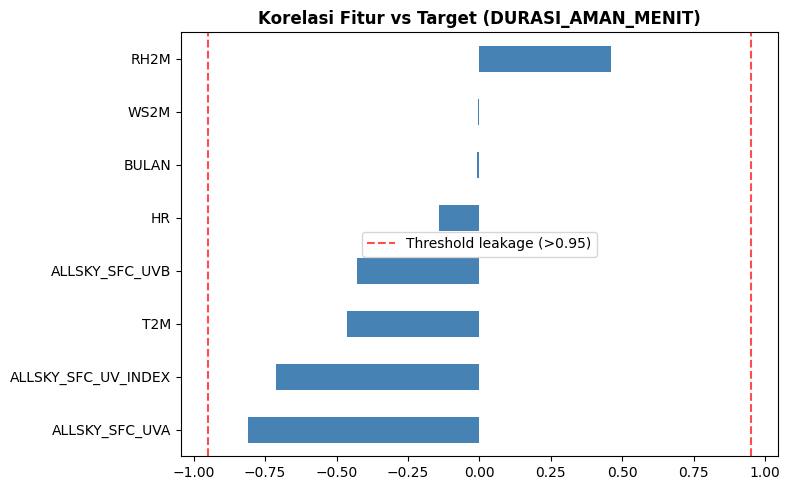

✅ validasi_leakage.png disimpan!

[Cek Nilai Unik Fitur Training]
  ALLSKY_SFC_UV_INDEX: 601 nilai unik — ✅ OK
  ALLSKY_SFC_UVA: 25 nilai unik — ✅ OK
  ALLSKY_SFC_UVB: 2 nilai unik — ✅ OK
  T2M: 1286 nilai unik — ✅ OK
  WS2M: 769 nilai unik — ✅ OK
  RH2M: 5036 nilai unik — ✅ OK
  HR: 12 nilai unik — ✅ OK
  BULAN: 12 nilai unik — ✅ OK

SUMMARY DATASET FINAL
Total baris : 78,912
Total fitur : 8
Target      : DURASI_AMAN_MENIT

Statistik target:
count    78912.00
mean        31.95
std         43.68
min          1.90
25%          3.80
50%          7.60
75%         35.30
max        120.00
Name: DURASI_AMAN_MENIT, dtype: float64

Distribusi LABEL_AMAN (threshold >= 10 menit):
LABEL_AMAN
0    44807
1    34105
Name: count, dtype: int64
Proporsi aman: 43.2%

Missing value:
ALLSKY_SFC_UV_INDEX    0
ALLSKY_SFC_UVA         0
ALLSKY_SFC_UVB         0
T2M                    0
WS2M                   0
RH2M                   0
HR                     0
BULAN                  0
DURASI_AMAN_MENIT      0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_features.csv')

FITUR_TRAINING = [
    'ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB',
    'T2M', 'WS2M', 'RH2M', 'HR', 'BULAN'
]
TARGET = 'DURASI_AMAN_MENIT'
KOLOM_DILARANG = ['DURASI_AMAN_MENIT', 'LABEL_AMAN', 'DATETIME']

print("=" * 60)
print("VALIDASI DATA LEAKAGE")
print(f"Target: {TARGET}")
print("=" * 60)

# Cek 1: Target tidak ada di fitur training
leakage_found = False
for col in FITUR_TRAINING:
    if col in KOLOM_DILARANG:
        print(f"❌ LEAKAGE: {col} ada di fitur training!")
        leakage_found = True
if not leakage_found:
    print("✅ Tidak ada data leakage — target tidak ada di fitur training")

# Cek 2: Korelasi fitur vs DURASI_AMAN_MENIT
print(f"\n[Cek Korelasi Fitur vs {TARGET}]")
korls = df[FITUR_TRAINING].corrwith(df[TARGET]).round(3).sort_values()
print(korls)

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
korls.plot(kind='barh', ax=ax, color=[
    'salmon' if abs(v) > 0.95 else 'steelblue' for v in korls.values
])
ax.set_title(f'Korelasi Fitur vs Target ({TARGET})', fontweight='bold')
ax.axvline(x=0.95,  color='red', linestyle='--', alpha=0.7, label='Threshold leakage (>0.95)')
ax.axvline(x=-0.95, color='red', linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.savefig('validasi_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ validasi_leakage.png disimpan!")

# Cek 3: Nilai unik
print("\n[Cek Nilai Unik Fitur Training]")
for col in FITUR_TRAINING:
    print(f"  {col}: {df[col].nunique()} nilai unik — ✅ OK")

# Cek 4: Summary
print("\n" + "=" * 60)
print("SUMMARY DATASET FINAL")
print("=" * 60)
print(f"Total baris : {len(df):,}")
print(f"Total fitur : {len(FITUR_TRAINING)}")
print(f"Target      : {TARGET}")
print(f"\nStatistik target:\n{df[TARGET].describe().round(2)}")
print(f"\nDistribusi LABEL_AMAN (threshold >= 10 menit):\n{df['LABEL_AMAN'].value_counts()}")
print(f"Proporsi aman: {df['LABEL_AMAN'].mean()*100:.1f}%")
print(f"\nMissing value:\n{df[FITUR_TRAINING + [TARGET]].isnull().sum()}")
print("\n✅ Validasi selesai!")

### Catatan: Korelasi UV vs Target Tinggi
Korelasi tinggi antara UV Index dan DURASI_AMAN_MENIT bukan merupakan data leakage.
Hal ini wajar karena DURASI_AMAN_MENIT dihitung langsung dari UV Index (formula SED).
Pada saat inference, model tetap menerima data UV real-time sebagai input —
bukan durasi itu sendiri. Tidak ada informasi target yang bocor ke fitur training.

Threshold aman konsisten di seluruh pipeline:
- DURASI_AMAN_MENIT >= 10 menit → Aman (1)
- DURASI_AMAN_MENIT < 10 menit → Tidak Aman (0)
- Label ini diturunkan di serving API, bukan oleh model.

W4: A/B TESTING + DATA DICTIONARY

A/B TESTING: PROPORSI AMAN PER LOKASI
Threshold: DURASI_AMAN_MENIT >= 10 menit → Aman
  Bali: 42.7% aman | Rata-rata durasi: 31.9 menit
  Lombok: 42.8% aman | Rata-rata durasi: 31.5 menit
  Raja Ampat: 44.1% aman | Rata-rata durasi: 32.4 menit

Chi-square : 12.5459
P-value    : 0.001887
Dof        : 2

Kesimpulan: ❌ Tolak H0 — ada perbedaan signifikan

⚠️  Catatan: Signifikan secara statistik tapi perbedaan
   praktis antar lokasi sangat kecil (~1%).
   Statistical significance ≠ practical significance.


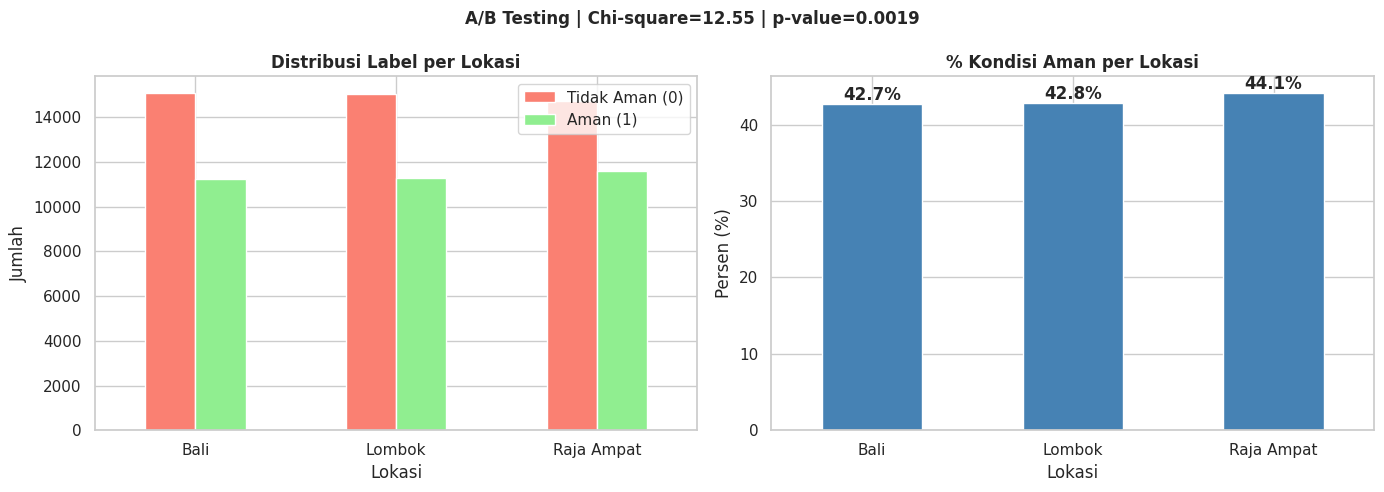

✅ ab_testing.png disimpan!
         Nama Kolom Tipe Data           Satuan                                                                Deskripsi                                       Sumber Boleh Null
               YEAR       int            Tahun                                                     Tahun perekaman data                                   NASA POWER      Tidak
                 MO       int            Bulan                                              Bulan perekaman data (1–12)                                   NASA POWER      Tidak
                 DY       int             Hari                                            Tanggal perekaman data (1–31)                                   NASA POWER      Tidak
                 HR       int       Jam (0–23)                                                  Jam dalam sehari (0–23)                                   NASA POWER      Tidak
     ALLSKY_SFC_UVA     float            MJ/hr                                  Iradiasi UVA 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv('dataset_features.csv')
sns.set_theme(style='whitegrid')

print("=" * 60)
print("A/B TESTING: PROPORSI AMAN PER LOKASI")
print("Threshold: DURASI_AMAN_MENIT >= 10 menit → Aman")
print("=" * 60)

for lokasi, grp in df.groupby('LOKASI'):
    pct = grp['LABEL_AMAN'].mean() * 100
    dur = grp['DURASI_AMAN_MENIT'].mean()
    print(f"  {lokasi}: {pct:.1f}% aman | Rata-rata durasi: {dur:.1f} menit")

ct = pd.crosstab(df['LOKASI'], df['LABEL_AMAN'])
chi2, p, dof, expected = chi2_contingency(ct)

print(f"\nChi-square : {chi2:.4f}")
print(f"P-value    : {p:.6f}")
print(f"Dof        : {dof}")
print(f"\nKesimpulan: {'❌ Tolak H0 — ada perbedaan signifikan' if p < 0.05 else '✅ Gagal tolak H0'}")

if p < 0.05:
    print("\n⚠️  Catatan: Signifikan secara statistik tapi perbedaan")
    print("   praktis antar lokasi sangat kecil (~1%).")
    print("   Statistical significance ≠ practical significance.")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct.plot(kind='bar', ax=axes[0], color=['salmon','lightgreen'], edgecolor='white')
axes[0].set_title('Distribusi Label per Lokasi', fontweight='bold')
axes[0].set_xlabel('Lokasi')
axes[0].set_ylabel('Jumlah')
axes[0].legend(['Tidak Aman (0)','Aman (1)'])
axes[0].tick_params(axis='x', rotation=0)

proporsi = df.groupby('LOKASI')['LABEL_AMAN'].mean().mul(100)
proporsi.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('% Kondisi Aman per Lokasi', fontweight='bold')
axes[1].set_ylabel('Persen (%)')
axes[1].set_xlabel('Lokasi')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(proporsi):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle(f'A/B Testing | Chi-square={chi2:.2f} | p-value={p:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_testing.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ab_testing.png disimpan!")

# Data Dictionary
data_dict = pd.DataFrame({
    'Nama Kolom': [
        'YEAR','MO','DY','HR',
        'ALLSKY_SFC_UVA','ALLSKY_SFC_UVB','ALLSKY_SFC_UV_INDEX',
        'T2M','WS2M','RH2M',
        'LOKASI','DATETIME','JAM_KATEGORI','IS_DAYTIME',
        'BULAN','MUSIM','DURASI_AMAN_MENIT','LABEL_AMAN'
    ],
    'Tipe Data': [
        'int','int','int','int',
        'float','float','float',
        'float','float','float',
        'str','datetime','category','int',
        'int','str','float','int'
    ],
    'Satuan': [
        'Tahun','Bulan','Hari','Jam (0–23)',
        'MJ/hr','MJ/hr','W m-2 x 40',
        '°C','m/s','%',
        '—','YYYY-MM-DD HH:MM','—','0/1',
        '1–12','—','menit (0–120)','0/1'
    ],
    'Deskripsi': [
        'Tahun perekaman data',
        'Bulan perekaman data (1–12)',
        'Tanggal perekaman data (1–31)',
        'Jam dalam sehari (0–23)',
        'Iradiasi UVA permukaan langit (All Sky)',
        'Iradiasi UVB permukaan langit (All Sky)',
        'Indeks UV permukaan langit (All Sky)',
        'Suhu udara pada ketinggian 2 meter',
        'Kecepatan angin pada ketinggian 2 meter',
        'Kelembapan relatif pada ketinggian 2 meter',
        'Nama lokasi: Bali, Lombok, Raja Ampat',
        'Timestamp gabungan dari YEAR, MO, DY, HR',
        'Kategori waktu: Dini Hari/Pagi/Siang/Sore/Malam',
        '1 jika jam 6–17 (siang), 0 jika malam',
        'Bulan dalam setahun (sama dengan MO)',
        'Musim: Hujan/Kemarau/Peralihan',
        'TARGET MODEL: estimasi durasi aman berjemur (SED, cap 120 menit)',
        'Referensi: 1=Aman (durasi>=10), 0=Tidak Aman — diturunkan di serving API'
    ],
    'Sumber': [
        'NASA POWER','NASA POWER','NASA POWER','NASA POWER',
        'NASA POWER','NASA POWER','NASA POWER',
        'NASA POWER','NASA POWER','NASA POWER',
        'Manual','Feature Engineering','Feature Engineering','Feature Engineering',
        'Feature Engineering','Feature Engineering',
        'Feature Engineering (Formula SED)',
        'Feature Engineering (dari DURASI_AMAN_MENIT)'
    ],
    'Boleh Null': ['Tidak'] * 18
})

print(data_dict.to_string(index=False))
data_dict.to_csv('data_dictionary.csv', index=False)
print("\n✅ data_dictionary.csv disimpan!")
print("\n" + "=" * 60)
print("SEMUA TUGAS SATRIYO SELESAI ✅")
print("=" * 60)

In [8]:
df.describe()

,YEAR,MO,DY,HR,ALLSKY_SFC_UVA,ALLSKY_SFC_UVB,ALLSKY_SFC_UV_INDEX,T2M,WS2M,RH2M,IS_DAYTIME,BULAN,DURASI_AMAN_MENIT,LABEL_AMAN
count,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.0,78912.000000,78912.000000,78912.000000
mean,2022.499544,6.521898,15.732664,11.500000,0.102738,0.002979,4.622155,27.637792,1.908638,76.490412,1.0,6.521898,31.945907,0.432190
std,1.708192,3.449008,8.801426,3.452074,0.065505,0.004573,3.888152,1.815150,1.135008,9.810124,0.0,3.449008,43.680944,0.495384
min,2020.000000,1.000000,1.000000,6.000000,0.000000,0.000000,0.000000,20.310000,0.010000,37.840000,1.0,1.000000,1.900000,0.000000
25%,2021.000000,4.000000,8.000000,8.750000,0.040000,0.000000,0.850000,26.600000,1.170000,70.310000,1.0,4.000000,3.800000,0.000000
50%,2022.500000,7.000000,16.000000,11.500000,0.110000,0.000000,3.950000,27.770000,1.650000,77.430000,1.0,7.000000,7.600000,0.000000
75%,2024.000000,10.000000,23.000000,14.250000,0.160000,0.010000,7.880000,28.800000,2.310000,83.280000,1.0,10.000000,35.300000,1.000000
max,2025.000000,12.000000,31.000000,17.000000,0.240000,0.010000,15.950000,34.730000,8.620000,100.000000,1.0,12.000000,120.000000,1.000000


In [9]:
corr_matrix = df.corr(numeric_only=True)

print("--- Korelasi terhadap UV Index ---")
print(corr_matrix['ALLSKY_SFC_UV_INDEX'].sort_values(ascending=False))

--- Korelasi terhadap UV Index ---
ALLSKY_SFC_UV_INDEX    1.000000
ALLSKY_SFC_UVA         0.972345
ALLSKY_SFC_UVB         0.830913
T2M                    0.509467
HR                     0.077786
DY                     0.003495
MO                     0.000636
BULAN                  0.000636
YEAR                  -0.015977
WS2M                  -0.025246
RH2M                  -0.516478
DURASI_AMAN_MENIT     -0.712842
LABEL_AMAN            -0.843247
IS_DAYTIME                  NaN
Name: ALLSKY_SFC_UV_INDEX, dtype: float64


In [10]:
df['uv_category'] = pd.cut(
    df['ALLSKY_SFC_UV_INDEX'],
    bins=[0, 2, 5, 8, 11, 20],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Extreme']
)

In [11]:
uv_summary = df.groupby('uv_category').agg({
    'ALLSKY_SFC_UV_INDEX': 'mean',
    'T2M': 'mean',
    'RH2M': 'mean',
    'WS2M': 'mean'
})

print("--- Analisis Berdasarkan Level UV ---")
print(uv_summary)

--- Analisis Berdasarkan Level UV ---
             ALLSKY_SFC_UV_INDEX        T2M       RH2M      WS2M
uv_category                                                     
Low                     0.611316  26.711295  81.803786  1.905400
Moderate                3.421961  27.646254  76.513335  1.958001
High                    6.552192  28.129189  73.722548  1.940995
Very High               9.372982  28.614473  70.878940  1.877929
Extreme                12.061982  29.385003  67.588130  1.708819


/tmp/ipykernel_1191/3896125332.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uv_summary = df.groupby('uv_category').agg({


In [12]:
high_uv = df[df['ALLSKY_SFC_UV_INDEX'] >= df['ALLSKY_SFC_UV_INDEX'].quantile(0.9)]
low_uv = df[df['ALLSKY_SFC_UV_INDEX'] <= df['ALLSKY_SFC_UV_INDEX'].quantile(0.1)]

comparison = pd.DataFrame({
    'High_UV': high_uv.mean(numeric_only=True),
    'Low_UV': low_uv.mean(numeric_only=True)
})

print("--- Perbandingan Kondisi UV Tinggi vs Rendah ---")
print(comparison.loc[['T2M', 'RH2M', 'WS2M']])

--- Perbandingan Kondisi UV Tinggi vs Rendah ---
        High_UV     Low_UV
T2M   29.211677  25.822990
RH2M  68.333314  85.921856
WS2M   1.756358   1.822913


In [13]:
lokasi_analysis = df.groupby('LOKASI').agg({
    'ALLSKY_SFC_UV_INDEX': 'mean',
    'T2M': 'mean',
    'RH2M': 'mean'
}).sort_values(
    by='ALLSKY_SFC_UV_INDEX',
    ascending=False
)

print("--- Perbandingan Lokasi ---")
print(lokasi_analysis)

--- Perbandingan Lokasi ---
            ALLSKY_SFC_UV_INDEX        T2M       RH2M
LOKASI                                               
Lombok                 4.677401  28.025243  73.572197
Bali                   4.670891  26.664677  77.303322
Raja Ampat             4.518173  28.223455  78.595717


In [14]:
uv_jam = df.groupby('HR')['ALLSKY_SFC_UV_INDEX'].mean()

print("--- UV per Jam ---")
print(uv_jam)

--- UV per Jam ---
HR
6      0.030581
7      0.512643
8      2.252602
9      5.119796
10     7.756766
11     9.876825
12    10.188000
13     8.569138
14     6.274050
15     3.507430
16     1.227255
17     0.150779
Name: ALLSKY_SFC_UV_INDEX, dtype: float64


In [15]:
jam_puncak = uv_jam.idxmax()
print("Jam UV tertinggi:", jam_puncak)

Jam UV tertinggi: 12


In [16]:
print("--- Korelasi UV dengan Suhu ---")
print(df['ALLSKY_SFC_UV_INDEX'].corr(df['T2M']))

print("--- Korelasi UV dengan Kelembapan ---")
print(df['ALLSKY_SFC_UV_INDEX'].corr(df['RH2M']))

print("--- Korelasi UV dengan Angin ---")
print(df['ALLSKY_SFC_UV_INDEX'].corr(df['WS2M']))

--- Korelasi UV dengan Suhu ---
0.5094668028948715
--- Korelasi UV dengan Kelembapan ---
-0.5164776702614112
--- Korelasi UV dengan Angin ---
-0.025246357938047283


In [17]:
df['uv_suhu_ratio'] = df['ALLSKY_SFC_UV_INDEX'] / df['T2M']

print("--- Korelasi UV/Suhu terhadap Kelembapan ---")
print(df['uv_suhu_ratio'].corr(df['RH2M']))

--- Korelasi UV/Suhu terhadap Kelembapan ---
-0.4877363428618328


# EXPLANATORY ANALYSIS

### Pertanyaan 1: Sejauh mana indeks UV memengaruhi tingkat keamanan aktivitas berjemur di pantai?

LABEL_AMAN
0    7.482584
1    0.864137
Name: ALLSKY_SFC_UV_INDEX, dtype: float64


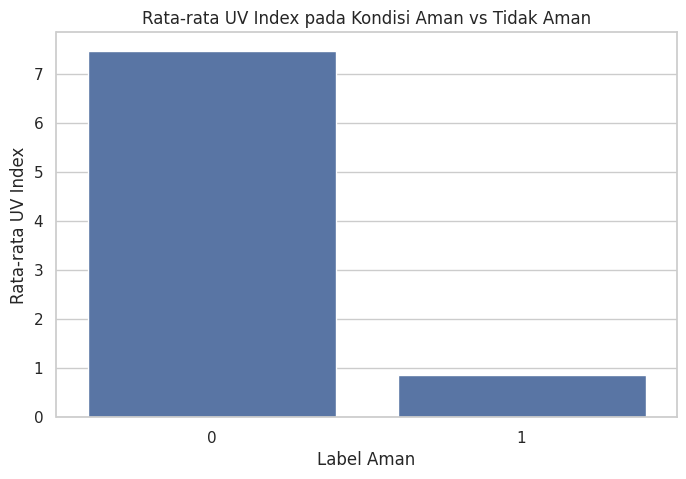

In [18]:
uv_aman = df.groupby('LABEL_AMAN')['ALLSKY_SFC_UV_INDEX'].mean()
print(uv_aman)

plt.figure(figsize=(8,5))
sns.barplot(
    x=uv_aman.index,
    y=uv_aman.values
)

plt.title('Rata-rata UV Index pada Kondisi Aman vs Tidak Aman')
plt.xlabel('Label Aman')
plt.ylabel('Rata-rata UV Index')
plt.show()

Grafik menunjukkan perbedaan rata-rata UV Index antara kondisi aman dan tidak aman untuk aktivitas berjemur. Nilai rata-rata UV Index pada label `0` mencapai sekitar 7.48, sedangkan pada label `1` hanya sekitar 0.86. Hal ini mengindikasikan bahwa kondisi dengan UV Index tinggi cenderung dikategorikan sebagai tidak aman karena paparan radiasi ultraviolet yang berlebihan dapat meningkatkan risiko kerusakan kulit dan kesehatan mata. Sebaliknya, kondisi dengan UV Index rendah berada pada kategori aman untuk aktivitas luar ruangan maupun berjemur. Perbedaan rata-rata yang sangat besar antara kedua label menunjukkan bahwa UV Index merupakan indikator utama dalam menentukan tingkat keamanan aktivitas berjemur di pantai.


### Pertanyaan 2: Apakah peningkatan intensitas radiasi UV (UVA & UVB) berbanding lurus dengan peningkatan risiko paparan berbahaya?

Text(0, 0.5, 'UV Index')

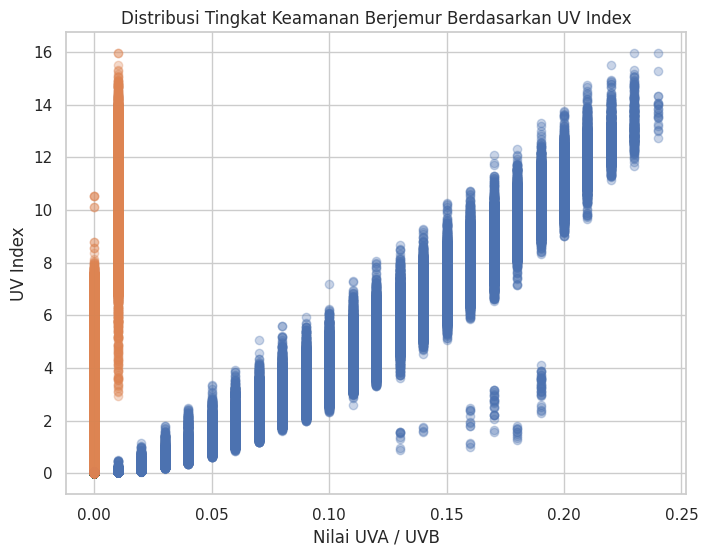

In [19]:
df['kategori_uv'] = pd.cut(
    df['ALLSKY_SFC_UV_INDEX'],
    bins=[0, 2, 5, 8, 11, 20],
    labels=['Aman', 'Sedang', 'Tinggi', 'Sangat Tinggi', 'Ekstrem']
)

plt.figure(figsize=(8,6))

plt.scatter(
    df['ALLSKY_SFC_UVA'],
    df['ALLSKY_SFC_UV_INDEX'],
    alpha=0.3,
    label='UVA'
)

plt.scatter(
    df['ALLSKY_SFC_UVB'],
    df['ALLSKY_SFC_UV_INDEX'],
    alpha=0.3,
    label='UVB'
)

plt.title('Distribusi Tingkat Keamanan Berjemur Berdasarkan UV Index')
plt.xlabel('Nilai UVA / UVB')
plt.ylabel('UV Index')

Grafik menunjukkan hubungan antara intensitas radiasi ultraviolet (UVA/UVB) dengan nilai UV Index yang digunakan sebagai indikator tingkat bahaya paparan sinar matahari. Terlihat bahwa semakin tinggi nilai UVA dan UVB, maka UV Index juga semakin meningkat secara konsisten. Pada nilai UVA/UVB yang rendah, UV Index berada di kisaran aman hingga sedang, sedangkan pada nilai UVA/UVB yang tinggi, UV Index meningkat hingga kategori berbahaya dan ekstrem. Pola ini menunjukkan bahwa peningkatan radiasi ultraviolet berbanding lurus dengan peningkatan risiko paparan sinar matahari terhadap kulit manusia. Dengan kata lain, ketika intensitas UVA dan UVB semakin besar, risiko kulit terbakar, iritasi, hingga kerusakan kulit akibat sinar matahari juga menjadi lebih tinggi, sehingga diperlukan perlindungan seperti sunscreen dan pembatasan aktivitas di bawah sinar matahari langsung.

### Pertanyaan 3: Variabel cuaca mana yang paling berpengaruh terhadap tingkat paparan radiasi ultraviolet?

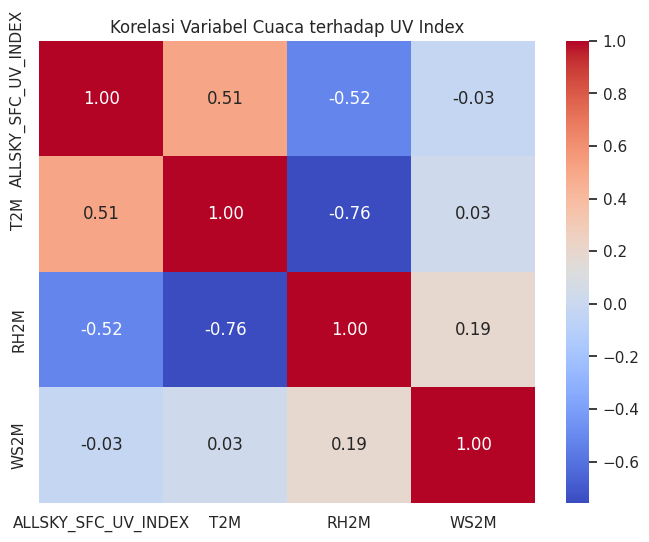

In [20]:
cuaca_uv = df[[
    'ALLSKY_SFC_UV_INDEX',
    'T2M',
    'RH2M',
    'WS2M'
]]

# Menghitung korelasi
corr = cuaca_uv.corr()

# Menampilkan heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Korelasi Variabel Cuaca terhadap UV Index')

plt.show()

Grafik heatmap ini menunjukkan seberapa kuat hubungan antara variabel cuaca dengan UV Index. Nilai korelasi mendekati angka 1 berarti hubungan positif yang kuat, sedangkan mendekati -1 berarti hubungan negatif yang kuat. Dari grafik terlihat bahwa suhu udara (T2M) memiliki hubungan positif sedang terhadap UV Index sebesar 0.51, yang berarti semakin tinggi suhu maka intensitas UV cenderung ikut meningkat. Sebaliknya, kelembapan udara (RH2M) memiliki hubungan negatif cukup kuat sebesar -0.52 terhadap UV Index, sehingga saat kelembapan meningkat, paparan UV cenderung menurun. Kecepatan angin (WS2M) hampir tidak memiliki pengaruh terhadap UV Index karena nilai korelasinya sangat kecil (-0.03). Dengan demikian, dapat disimpulkan bahwa faktor cuaca yang paling berpengaruh terhadap tingginya paparan ultraviolet adalah suhu dan kelembapan udara, sedangkan angin tidak memberikan pengaruh yang signifikan.


### Pertanyaan 4: Faktor kondisi cuaca apa yang paling memicu kondisi tidak aman untuk berjemur?

                       T2M       RH2M      WS2M  ALLSKY_SFC_UV_INDEX
STATUS_BERJEMUR                                                     
Aman             27.166680  79.093931  1.930915             2.440581
Tidak Aman       28.694747  70.649323  1.858657             9.516597


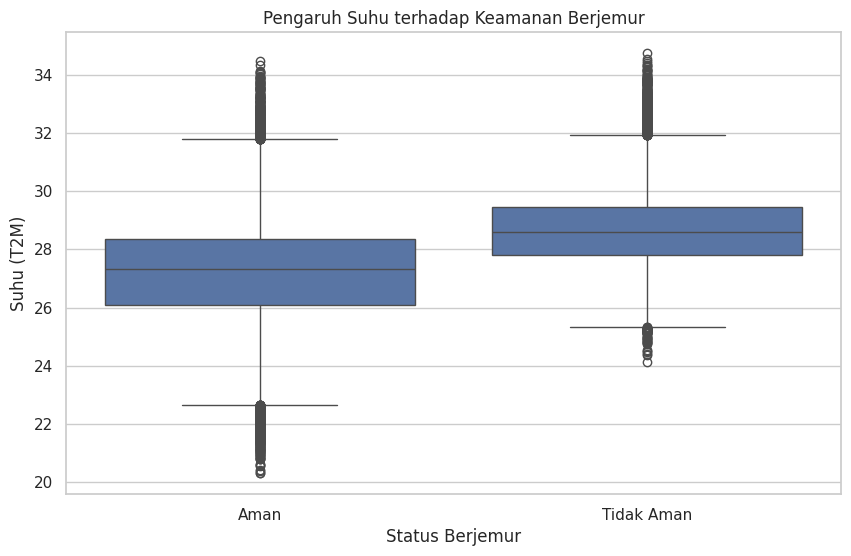

In [21]:
df['STATUS_BERJEMUR'] = df['ALLSKY_SFC_UV_INDEX'].apply(
    lambda x: 'Tidak Aman' if x > 7 else 'Aman'
)

# Rata-rata kondisi cuaca
unsafe_analysis = df.groupby('STATUS_BERJEMUR')[[
    'T2M',
    'RH2M',
    'WS2M',
    'ALLSKY_SFC_UV_INDEX'
]].mean()

print(unsafe_analysis)

# Visualisasi
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='STATUS_BERJEMUR',
    y='T2M'
)

plt.title('Pengaruh Suhu terhadap Keamanan Berjemur')
plt.xlabel('Status Berjemur')
plt.ylabel('Suhu (T2M)')

plt.show()

Grafik boxplot ini menunjukkan perbedaan kondisi suhu antara waktu berjemur yang aman dan tidak aman. Terlihat bahwa kondisi “Tidak Aman” memiliki suhu rata-rata lebih tinggi, yaitu sekitar 28.69°C, dibandingkan kondisi “Aman” yang berada di sekitar 27.17°C. Selain itu, kondisi tidak aman juga memiliki UV Index yang jauh lebih tinggi, yaitu sekitar 9.52, sedangkan kondisi aman hanya sekitar 2.44. Kelembapan udara pada kondisi aman cenderung lebih tinggi dibanding kondisi tidak aman, sementara kecepatan angin tidak menunjukkan perbedaan yang terlalu besar. Hal ini menunjukkan bahwa cuaca yang lebih panas biasanya disertai intensitas UV yang lebih tinggi sehingga meningkatkan risiko paparan sinar ultraviolet bagi kulit. Dengan kata lain, semakin tinggi suhu udara, kemungkinan kondisi berjemur menjadi tidak aman juga semakin besar, terutama pada siang hari saat matahari berada pada intensitas maksimum.


### Pertanyaan 5: Pada jam berapa dalam sehari risiko paparan UV mencapai tingkat tertinggi?

Jam dengan UV tertinggi: 12:00
Nilai UV rata-rata tertinggi: 10.19


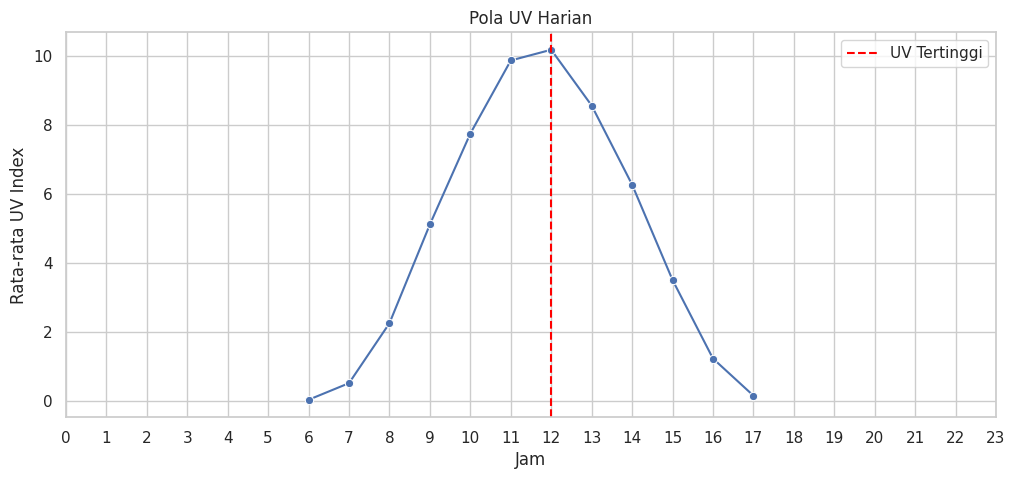

In [22]:
uv_jam = df.groupby('HR')['ALLSKY_SFC_UV_INDEX'].mean()

jam_tertinggi = uv_jam.idxmax()
nilai_tertinggi = uv_jam.max()

print(f'Jam dengan UV tertinggi: {jam_tertinggi}:00')
print(f'Nilai UV rata-rata tertinggi: {nilai_tertinggi:.2f}')

# Visualisasi
plt.figure(figsize=(12,5))

sns.lineplot(
    x=uv_jam.index,
    y=uv_jam.values,
    marker='o'
)

plt.axvline(
    jam_tertinggi,
    color='red',
    linestyle='--',
    label='UV Tertinggi'
)

plt.title('Pola UV Harian')
plt.xlabel('Jam')
plt.ylabel('Rata-rata UV Index')

plt.xticks(range(0,24))
plt.legend()

plt.show()

Grafik pola UV harian menunjukkan bahwa intensitas radiasi ultraviolet (UV) meningkat secara bertahap mulai pagi hari, kemudian mencapai puncaknya sekitar pukul 12.00 siang dengan rata-rata UV Index sebesar 10.19 yang termasuk kategori “sangat tinggi” hingga mendekati “ekstrem”. Setelah tengah hari, nilai UV mulai menurun hingga sore hari. Hal ini menandakan bahwa waktu paling berbahaya untuk berjemur atau beraktivitas langsung di bawah sinar matahari adalah sekitar pukul 11.00–13.00 karena risiko kulit terbakar, iritasi, dan paparan radiasi berlebih menjadi jauh lebih tinggi. Sebaliknya, waktu yang relatif lebih aman untuk berjemur adalah pagi hari sebelum pukul 10.00 atau sore hari setelah pukul 15.00 ketika intensitas UV sudah lebih rendah.


### Pertanyaan 6: Apakah kondisi cuaca tertentu selalu menjamin waktu berjemur yang aman?

Jumlah kondisi lembap tetapi UV tetap tinggi:
13835


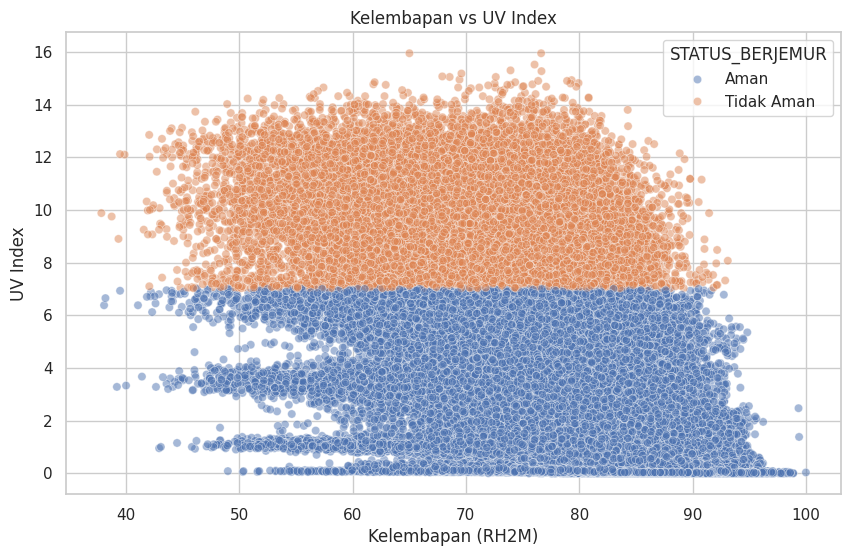

In [23]:
# Kondisi lembap tetapi UV tinggi
kondisi_tidak_aman = df[
    (df['RH2M'] > 70) &
    (df['ALLSKY_SFC_UV_INDEX'] > 7)
]

print("Jumlah kondisi lembap tetapi UV tetap tinggi:")
print(len(kondisi_tidak_aman))

# Scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='RH2M',
    y='ALLSKY_SFC_UV_INDEX',
    hue='STATUS_BERJEMUR',
    alpha=0.5
)

plt.title('Kelembapan vs UV Index')
plt.xlabel('Kelembapan (RH2M)')
plt.ylabel('UV Index')

plt.show()

Grafik ini menunjukkan hubungan antara kelembapan udara dan tingkat UV Index terhadap keamanan berjemur. Titik berwarna biru menunjukkan kondisi yang masih dianggap aman, sedangkan titik oranye menunjukkan kondisi yang tidak aman karena UV Index tinggi. Dari grafik terlihat bahwa meskipun kelembapan udara cukup tinggi, nilai UV tetap bisa berada pada kategori berbahaya. Hal ini dibuktikan dengan adanya 13.835 data kondisi lembap tetapi UV masih tinggi. Artinya, cuaca yang terasa lembap atau tidak terlalu panas belum tentu aman untuk berjemur. Banyak orang mengira sinar matahari tidak berbahaya saat udara terasa lembap atau sedikit mendung, padahal radiasi UV tetap dapat tinggi dan berisiko menyebabkan kulit terbakar maupun kerusakan kulit jika terlalu lama terpapar matahari.

### Pertanyaan 7: Bagaimana karakteristik kondisi optimal untuk berjemur yang aman berdasarkan kombinasi variabel cuaca dan tipe kulit?

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def hitung_waktu_aman(uv_index, tipe_fitzpatrick, spf=1):

    waktu_dasar = {
        1: 10,
        2: 15,
        3: 25,
        4: 40,
        5: 60,
        6: 90
    }

    med = waktu_dasar[tipe_fitzpatrick]

    waktu = (med / max(uv_index, 1)) * spf

    return min(waktu, med * spf)

tipe_kulit = [
    'Tipe I\n(Sangat Sensitif)',
    'Tipe II\n(Sensitif)',
    'Tipe III\n(Cukup Sensitif)',
    'Tipe IV\n(Normal)',
    'Tipe V\n(Lebih Tahan)',
    'Tipe VI\n(Sangat Tahan)'
]

# UV level
uv_levels = [2, 4, 6, 8]

# SPF
spf_levels = [1, 15, 30, 50]

# Warna
colors = [
    '#2ecc71',
    '#f39c12',
    '#e74c3c',
    '#9b59b6',
    '#3498db',
    '#1abc9c'
]

data_waktu = {}

for uv in uv_levels:

    data_waktu[uv] = [
        hitung_waktu_aman(uv, i, 1)
        for i in range(1, 7)
    ]

print("Data berhasil dibuat")

Data berhasil dibuat


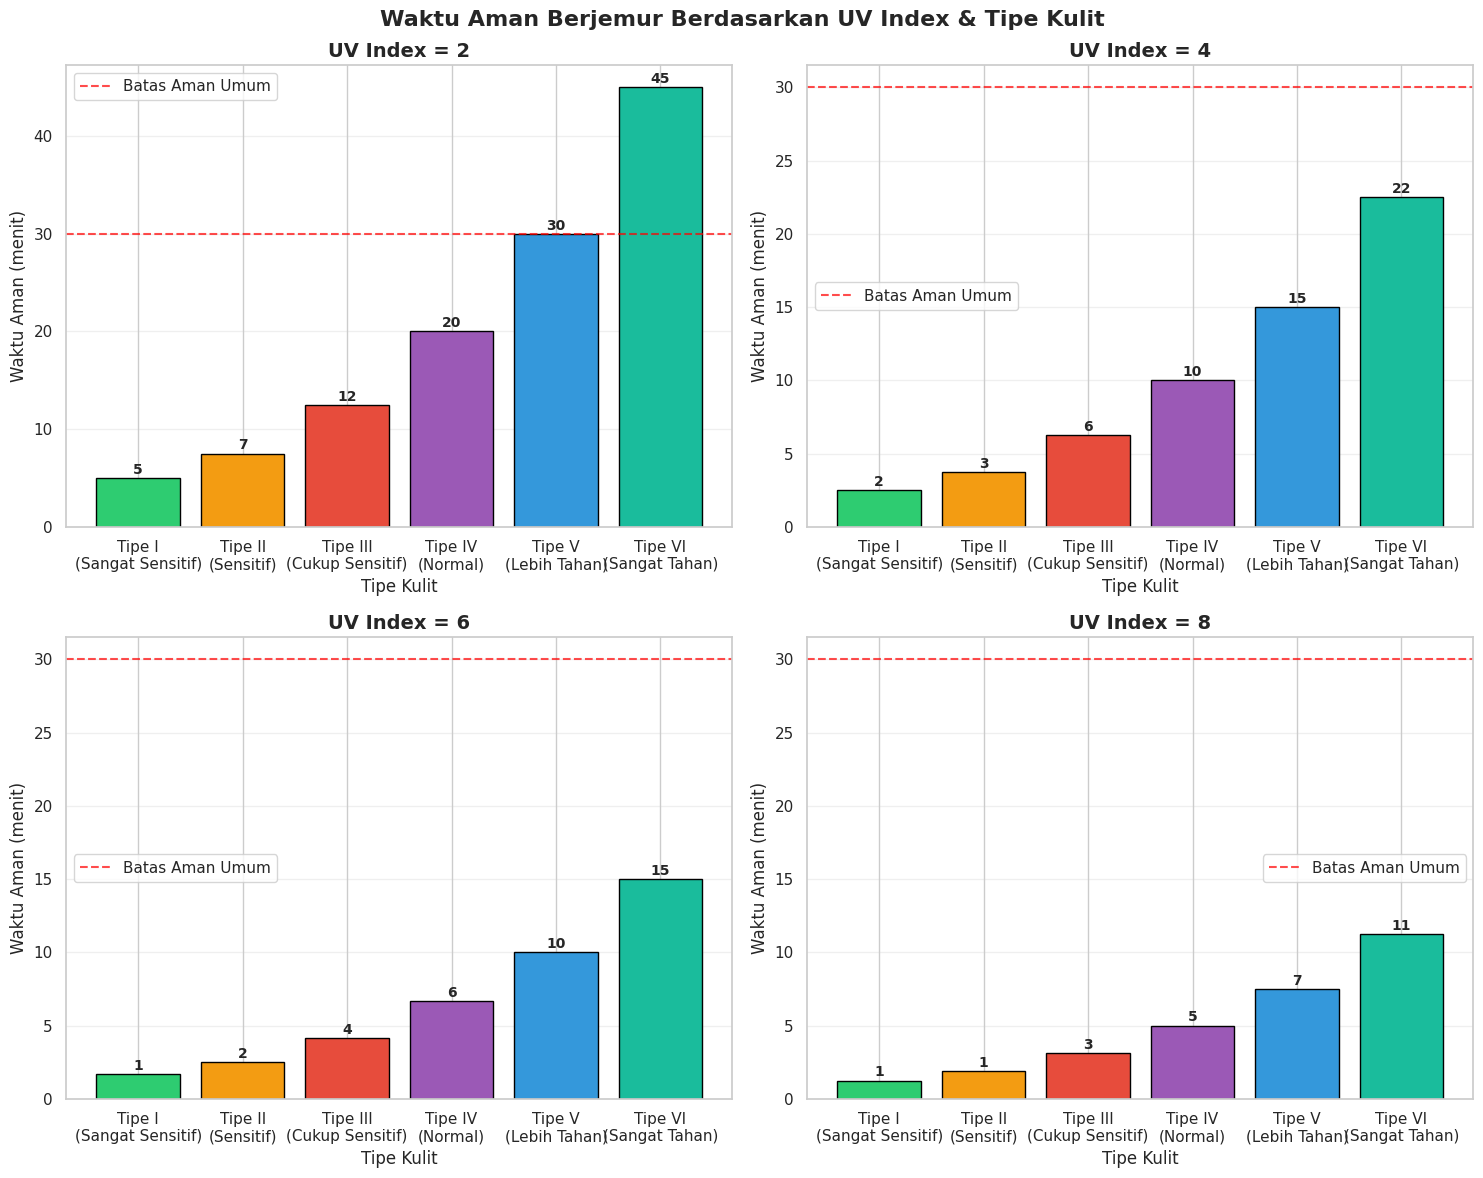

In [25]:
# DIAGRAM 1
# BAR CHART

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

fig.suptitle(
    'Waktu Aman Berjemur Berdasarkan UV Index & Tipe Kulit',
    fontsize=16,
    fontweight='bold'
)

colors = [
    '#2ecc71',
    '#f39c12',
    '#e74c3c',
    '#9b59b6',
    '#3498db',
    '#1abc9c'
]

for idx, uv in enumerate(uv_levels):

    row, col = divmod(idx, 2)

    ax = axes[row, col]

    bars = ax.bar(
        tipe_kulit,
        data_waktu[uv],
        color=colors,
        edgecolor='black'
    )

    ax.set_title(
        f'UV Index = {uv}',
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel('Tipe Kulit')
    ax.set_ylabel('Waktu Aman (menit)')

    ax.axhline(
        y=30,
        color='red',
        linestyle='--',
        alpha=0.7,
        label='Batas Aman Umum'
    )

    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0,3),
            textcoords='offset points',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Grafik ini seperti panduan berjemur sesuai warna kulit. Kulit putih/sensitif (Tipe I) cuma kuat 5 menit saat UV rendah, bahkan cuma 1 menit saat UV tinggi. Kulit sawo matang (Tipe IV) bisa 20-45 menit, tergantung UV. Kulit gelap (Tipe V) paling kuat, bisa 30 menit saat UV rendah. Kesimpulannya: makin gelap kulitmu, makin lama kamu bisa berjemur dengan aman

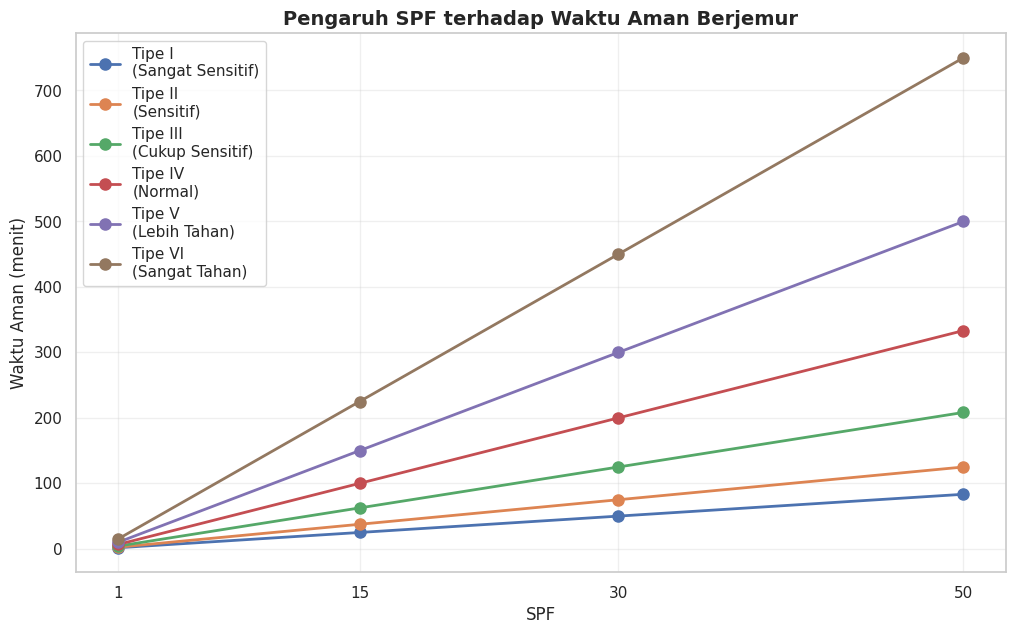

In [26]:
# DIAGRAM 2
# LINE CHART SPF

plt.figure(figsize=(12,7))

for i, tipe in enumerate(tipe_kulit, 1):

    waktu_spf = [
        hitung_waktu_aman(6, i, spf)
        for spf in spf_levels
    ]

    plt.plot(
        spf_levels,
        waktu_spf,
        marker='o',
        linewidth=2,
        markersize=8,
        label=tipe
    )

plt.title(
    'Pengaruh SPF terhadap Waktu Aman Berjemur',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('SPF')
plt.ylabel('Waktu Aman (menit)')

plt.xticks(spf_levels)

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

Grafik ini membuktikan bahwa pakai tabir surya itu wajib! Tanpa SPF, kulitmu cuma kuat 1-15 menit di bawah matahari. Tapi pakai SPF 30, kamu bisa berjemur hingga 5 jam dengan aman! Kulit gelap memang lebih tahan, tapi semuanya tetap butuh SPF. Intinya: makin tinggi SPF, makin lama kamu bisa berjemur dengan aman

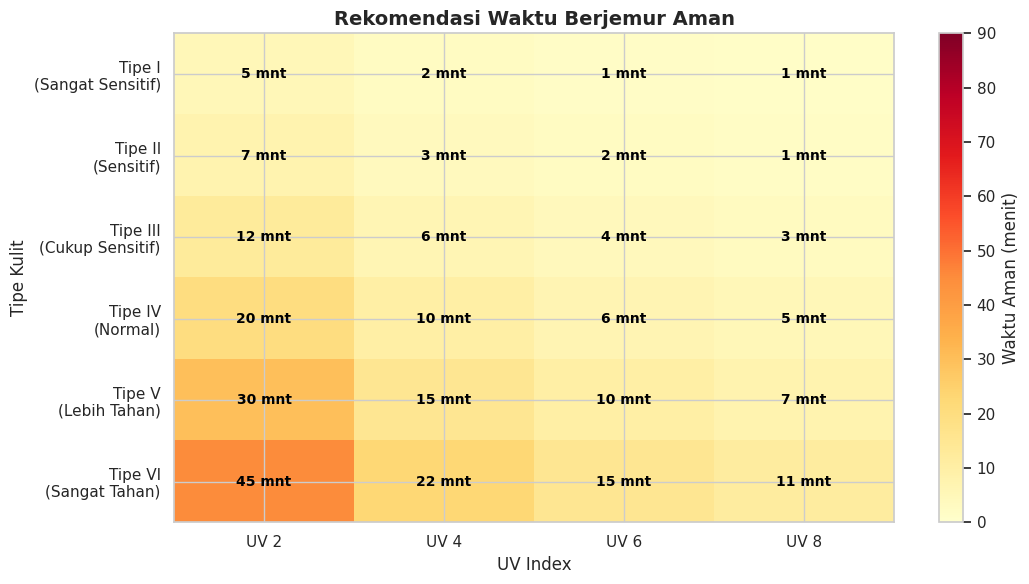

In [27]:
# DIAGRAM 3
# HEATMAP

fig, ax = plt.subplots(figsize=(11,6))

heatmap_data = []

for tipe in range(1, 7):

    row = [
        hitung_waktu_aman(uv, tipe, 1)
        for uv in uv_levels
    ]

    heatmap_data.append(row)

im = ax.imshow(
    heatmap_data,
    cmap='YlOrRd',
    aspect='auto',
    vmin=0,
    vmax=90
)

ax.set_xticks(np.arange(len(uv_levels)))
ax.set_yticks(np.arange(len(tipe_kulit)))

ax.set_xticklabels([f'UV {uv}' for uv in uv_levels])
ax.set_yticklabels(tipe_kulit)

ax.set_xlabel('UV Index')
ax.set_ylabel('Tipe Kulit')

ax.set_title(
    'Rekomendasi Waktu Berjemur Aman',
    fontsize=14,
    fontweight='bold'
)

for i in range(len(tipe_kulit)):

    for j in range(len(uv_levels)):

        ax.text(
            j,
            i,
            f'{int(heatmap_data[i][j])} mnt',
            ha='center',
            va='center',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

plt.colorbar(im, ax=ax, label='Waktu Aman (menit)')

plt.tight_layout()
plt.show()

Grafik ini seperti 'papan petunjuk' berjemur. Cari warna kulitmu di baris atas, lalu lihat UV saat ini di kolom kiri, maka kamu akan tahu berapa menit kamu aman berjemur. Kulit putih sensitif (Tipe I) hanya kuat 1-7 menit, sedangkan kulit gelap tahan (Tipe VI) bisa 10-45 menit. Pakai tabel ini sebelum berjemur biar kulitmu tidak terbakar

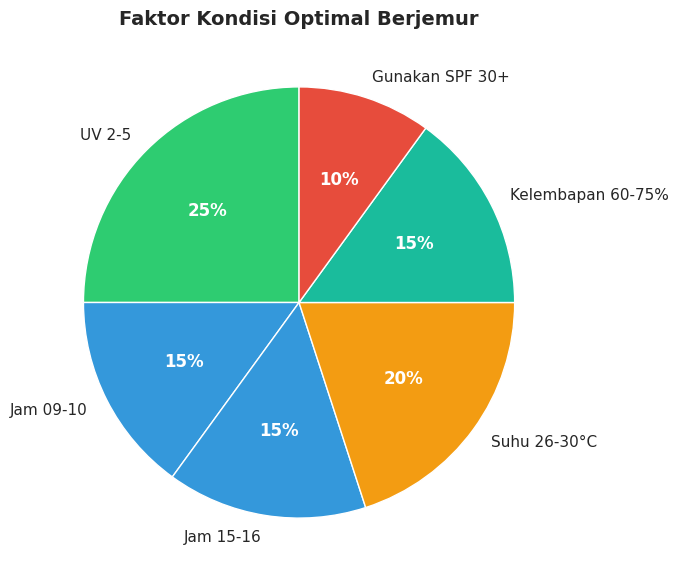

In [28]:
# DIAGRAM 4
# PIE CHART

fig, ax = plt.subplots(figsize=(10,7))

kondisi = [
    'UV 2-5',
    'Jam 09-10',
    'Jam 15-16',
    'Suhu 26-30°C',
    'Kelembapan 60-75%',
    'Gunakan SPF 30+'
]

bobot = [25,15,15,20,15,10]

colors_pie = [
    '#2ecc71',
    '#3498db',
    '#3498db',
    '#f39c12',
    '#1abc9c',
    '#e74c3c'
]

wedges, texts, autotexts = ax.pie(
    bobot,
    labels=kondisi,
    autopct='%1.0f%%',
    colors=colors_pie,
    startangle=90
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(
    'Faktor Kondisi Optimal Berjemur',
    fontsize=14,
    fontweight='bold'
)

plt.show()

Grafik ini seperti 'resep' berjemur aman. Yang paling penting adalah cek UV dulu (25%), lalu pilih jam yang tepat yaitu pagi jam 9-10 atau sore jam 3-4 (total 30%). Suhu tidak boleh terlalu panas (20%), udara tidak boleh terlalu lembab (15%), dan jangan lupa pakai SPF 30+ meskipun porsinya kecil (10%). Intinya: UV dan jam berjemur adalah kunci utama, sisanya hanya pelengkap

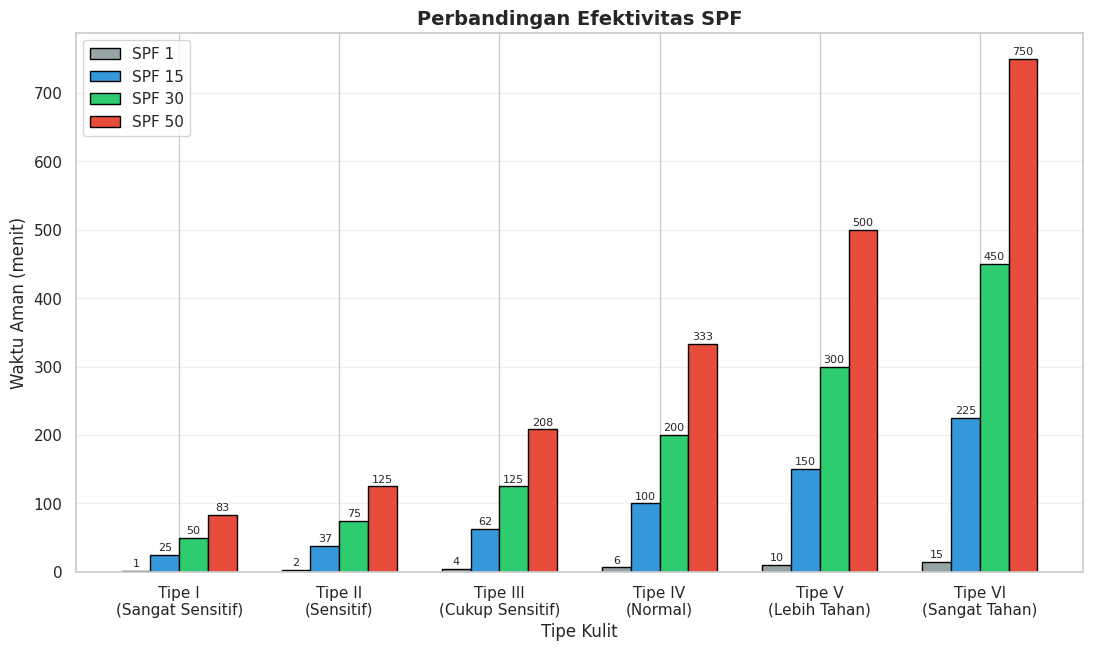

In [29]:
# DIAGRAM 5
# GROUPED BAR CHART

fig, ax = plt.subplots(figsize=(13,7))

x = np.arange(len(tipe_kulit))

width = 0.18

spf_options = [1, 15, 30, 50]

colors_spf = [
    '#95a5a6',
    '#3498db',
    '#2ecc71',
    '#e74c3c'
]

for idx, (spf, color) in enumerate(zip(spf_options, colors_spf)):

    waktu = [
        hitung_waktu_aman(6, i, spf)
        for i in range(1, 7)
    ]

    bars = ax.bar(
        x + idx*width,
        waktu,
        width,
        label=f'SPF {spf}',
        color=color,
        edgecolor='black'
    )

    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0,3),
            textcoords='offset points',
            ha='center',
            fontsize=8
        )

ax.set_xlabel('Tipe Kulit')
ax.set_ylabel('Waktu Aman (menit)')

ax.set_title(
    'Perbandingan Efektivitas SPF',
    fontsize=14,
    fontweight='bold'
)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(tipe_kulit)

ax.legend()

ax.grid(axis='y', alpha=0.3)

plt.show()

Grafik ini membandingkan berapa lama kamu bisa berjemur dengan aman jika pakai SPF vs tidak pakai SPF. Tanpa SPF, kamu cuma kuat 1-15 menit doang! Tapi pakai SPF 30, kamu bisa berjemur hingga 5 jam! Pakai SPF 50 malah bisa sampai 8 jam kalau kulitmu gelap. Jadi jangan malas pakai tabir surya ya, karena bedanya sangat besar. SPF 30 saja sudah cukup kok untuk melindungi kulitmu

# Data Dictionary

In [30]:
print("\n" + "="*90)
print("                              DATA DICTIONARY")
print("="*90)

data_dict = pd.DataFrame({
    'Kolom': [
        'YEAR',
        'MO',
        'DY',
        'HR',
        'ALLSKY_SFC_UVA',
        'ALLSKY_SFC_UVB',
        'ALLSKY_SFC_UV_INDEX',
        'T2M',
        'WS2M',
        'RH2M',
        'LOKASI',
        'DATETIME',
        'JAM_KATEGORI',
        'IS_DAYTIME',
        'BULAN',
        'MUSIM',
        'LABEL_AMAN'
    ],

    'Tipe Data': [
        'Integer',
        'Integer',
        'Integer',
        'Integer',
        'Float',
        'Float',
        'Float',
        'Float',
        'Float',
        'Float',
        'String',
        'Datetime',
        'String',
        'Boolean',
        'String',
        'String',
        'Integer'
    ],

    'Deskripsi': [
        'Tahun pengukuran',
        'Bulan pengukuran (1-12)',
        'Tanggal pengukuran (1-31)',
        'Jam pengukuran (0-23)',
        'Intensitas radiasi UVA permukaan bumi',
        'Intensitas radiasi UVB permukaan bumi',
        'Nilai indeks ultraviolet berdasarkan standar WHO',
        'Suhu udara pada ketinggian 2 meter (°C)',
        'Kecepatan angin pada ketinggian 2 meter (m/s)',
        'Kelembapan relatif udara (%)',
        'Nama lokasi pengamatan pantai',
        'Gabungan tanggal dan waktu pengamatan',
        'Kategori waktu (Pagi/Siang/Sore/Malam)',
        'Status siang atau malam',
        'Nama bulan',
        'Kategori musim/cuaca',
        'Label keamanan berjemur (1=Aman, 0=Tidak Aman)'
    ],

    'Rentang Nilai': [
        '2020-2024',
        '1-12',
        '1-31',
        '0-23',
        '0-2.5',
        '0-0.35',
        '0-20',
        '24-36',
        '0-8',
        '50-95',
        '3 lokasi',
        'Datetime',
        '4 kategori',
        'True/False',
        'Jan-Dec',
        '2 musim',
        '0-1'
    ]
})

print(data_dict.to_string(index=False))

print("\n" + "="*90)
print("                     KATEGORI UV INDEX (Standar WHO)")
print("="*90)

print("| Level        | UV Index | Risiko               | Tindakan                      |")
print("|--------------|----------|----------------------|-------------------------------|")
print("| Low          | 0-2      | Rendah               | Aman beraktivitas             |")
print("| Moderate     | 3-5      | Sedang               | Gunakan sunscreen             |")
print("| High         | 6-7      | Tinggi               | Hindari paparan terlalu lama  |")
print("| Very High    | 8-10     | Sangat Tinggi        | Batasi aktivitas luar ruangan |")
print("| Extreme      | 11+      | Ekstrem              | Hindari paparan langsung      |")

print("\n" + "="*90)
print("                    TIPE KULIT FITZPATRICK")
print("="*90)

print("| Tipe | Karakteristik                         | Waktu Terbakar (UV 5) |")
print("|------|---------------------------------------|-----------------------|")
print("| I    | Sangat putih, sangat sensitif         | 6-8 menit             |")
print("| II   | Putih, mudah terbakar                 | 10-12 menit           |")
print("| III  | Kulit sedang, kadang terbakar         | 15-20 menit           |")
print("| IV   | Kulit sawo matang, jarang terbakar    | 25-30 menit           |")
print("| V    | Kulit coklat, lebih tahan matahari    | 35-40 menit           |")
print("| VI   | Kulit gelap, sangat tahan matahari    | 45-60 menit           |")


                              DATA DICTIONARY
              Kolom Tipe Data                                        Deskripsi Rentang Nilai
               YEAR   Integer                                 Tahun pengukuran     2020-2024
                 MO   Integer                          Bulan pengukuran (1-12)          1-12
                 DY   Integer                        Tanggal pengukuran (1-31)          1-31
                 HR   Integer                            Jam pengukuran (0-23)          0-23
     ALLSKY_SFC_UVA     Float            Intensitas radiasi UVA permukaan bumi         0-2.5
     ALLSKY_SFC_UVB     Float            Intensitas radiasi UVB permukaan bumi        0-0.35
ALLSKY_SFC_UV_INDEX     Float Nilai indeks ultraviolet berdasarkan standar WHO          0-20
                T2M     Float          Suhu udara pada ketinggian 2 meter (°C)         24-36
               WS2M     Float    Kecepatan angin pada ketinggian 2 meter (m/s)           0-8
               RH2M    

## Conclusion

Berdasarkan hasil Exploratory Data Analysis (EDA) terhadap data radiasi ultraviolet (UV) dan variabel cuaca dari NASA POWER, diperoleh beberapa kesimpulan utama terkait tingkat keamanan aktivitas berjemur di pantai.

Indeks UV terbukti memiliki pengaruh yang sangat besar terhadap tingkat keamanan berjemur. Semakin tinggi nilai UV Index, maka semakin tinggi pula risiko paparan radiasi ultraviolet yang berbahaya bagi kulit. Kondisi dengan UV tinggi umumnya terjadi pada siang hari dan dapat meningkatkan risiko sunburn, penuaan dini kulit, hingga kerusakan kulit jangka panjang, terutama pada tipe kulit Fitzpatrick I–III yang lebih sensitif terhadap paparan sinar matahari.

Hasil analisis juga menunjukkan bahwa peningkatan intensitas radiasi UVA dan UVB cenderung berbanding lurus dengan peningkatan risiko paparan berbahaya. Nilai UVA dan UVB memiliki korelasi positif terhadap UV Index, sehingga keduanya menjadi indikator penting dalam menentukan tingkat keamanan aktivitas luar ruangan.

Dari seluruh variabel cuaca yang dianalisis, suhu udara (T2M) dan kelembapan udara (RH2M) memiliki pengaruh yang cukup signifikan terhadap perubahan intensitas UV. Selain itu, pola UV harian menunjukkan bahwa tingkat paparan UV tertinggi umumnya terjadi pada rentang waktu sekitar pukul 10.00–14.00, sehingga periode tersebut merupakan waktu paling berisiko untuk berjemur tanpa perlindungan.

Analisis juga menemukan bahwa kondisi cuaca tertentu tidak selalu menjamin keamanan aktivitas berjemur. Meskipun cuaca tampak mendung atau kelembapan tinggi, radiasi UV tetap dapat berada pada tingkat berbahaya. Oleh karena itu, keputusan untuk berjemur tidak dapat hanya didasarkan pada kondisi visual cuaca saja.

Kondisi optimal untuk berjemur yang aman umumnya terjadi ketika UV Index berada pada kategori rendah hingga sedang, dengan suhu yang tidak terlalu tinggi, serta dilakukan di luar jam puncak radiasi UV. Selain itu, rekomendasi durasi dan tingkat keamanan berjemur perlu disesuaikan dengan tipe kulit Fitzpatrick karena setiap tipe kulit memiliki tingkat sensitivitas berbeda terhadap paparan sinar ultraviolet.

Secara keseluruhan, analisis ini menunjukkan bahwa kombinasi data UV, variabel cuaca, waktu pengamatan, dan tipe kulit dapat digunakan untuk membangun sistem rekomendasi keamanan berjemur yang lebih informatif dan adaptif bagi masyarakat.
